In [1]:
# Numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and splitting
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Decision-boundary visualization
from mlxtend.plotting import plot_decision_regions

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
X, y = make_circles(
    n_samples=1000,
    noise=0.10,
    factor=0.50,
    random_state=1
)

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

print("\nFirst 5 features:")
print(X[:5])

print("\nFirst 5 targets:")
print(y[:5])

Feature shape: (1000, 2)
Target shape : (1000,)

First 5 features:
[[ 0.6290374  -0.07157267]
 [-0.3460561  -0.52817133]
 [ 0.9246533  -0.71492522]
 [-0.10217077 -0.89283523]
 [-1.01719242  0.24737775]]

First 5 targets:
[1 1 0 0 0]


In [3]:
# Convert the dataset into a DataFrame for inspection
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df["Target"] = y

print(df.head())
print("\nClass distribution:")
print(df["Target"].value_counts().sort_index())

   Feature_1  Feature_2  Target
0   0.629037  -0.071573       1
1  -0.346056  -0.528171       1
2   0.924653  -0.714925       0
3  -0.102171  -0.892835       0
4  -1.017192   0.247378       0

Class distribution:
Target
0    500
1    500
Name: count, dtype: int64


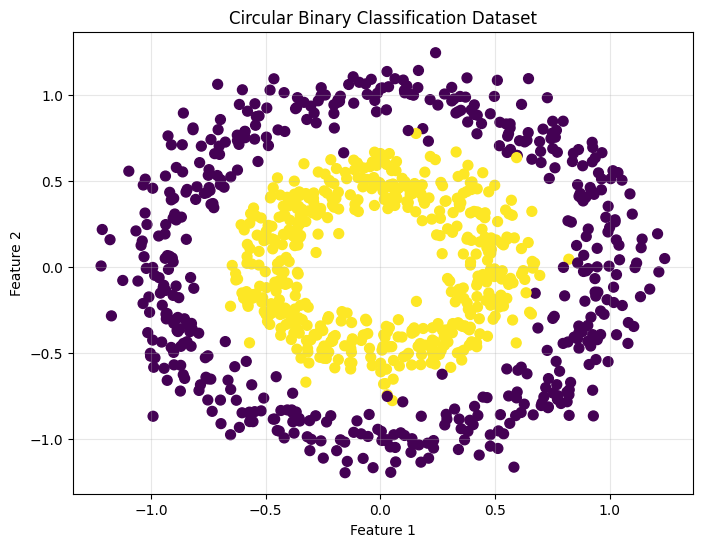

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Circular Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# First: hold out 20% for final testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Second: split the remaining 80% into 80% training and 20% validation
# This gives 64% train, 16% validation, and 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_val
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

Training samples  : 640
Validation samples: 160
Testing samples   : 200

X_train shape: (640, 2)
X_val shape  : (160, 2)
X_test shape : (200, 2)

y_train shape: (640,)
y_val shape  : (160,)
y_test shape : (200,)


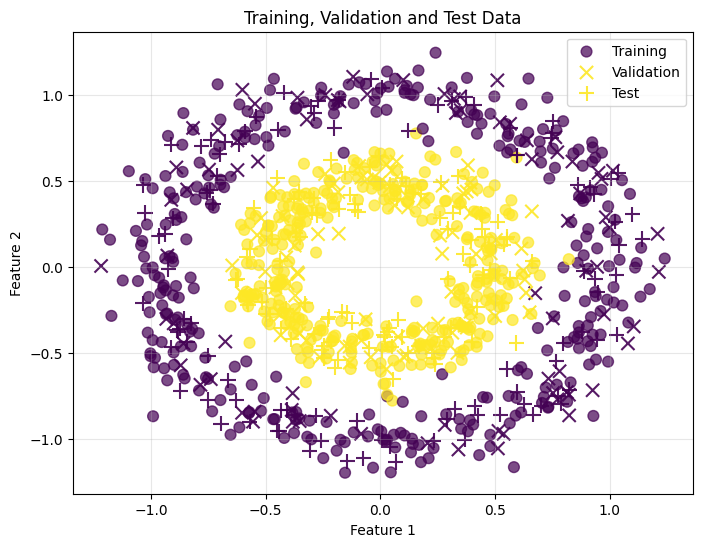

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=60, alpha=0.7, label="Training")
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, s=90, marker="x", alpha=0.9, label="Validation")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=120, marker="+", alpha=0.9, label="Test")

plt.title("Training, Validation and Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
def build_model():
    model = Sequential([
        Input(shape=(2,), name="Input_Layer"),
        Dense(256, activation="relu", name="Hidden_Layer"),
        Dense(1, activation="sigmoid", name="Output_Layer")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Maximum number of epochs for the comparison
MAX_EPOCHS = 1000

model = build_model()

history_no_es = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    verbose=0
)

print("Training completed.")
print("Epochs executed:", len(history_no_es.history["loss"]))

In [ ]:
history_no_es_df = pd.DataFrame(history_no_es.history)

print(history_no_es_df.head())

print("\nLast 10 epochs:")
print(history_no_es_df.tail(10))

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_es.history["loss"], label="Training Loss")
plt.plot(history_no_es.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss — Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_es.history["accuracy"], label="Training Accuracy")
plt.plot(history_no_es.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy — Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
val_loss_no_es = np.asarray(history_no_es.history["val_loss"])
best_epoch_no_es = int(np.argmin(val_loss_no_es) + 1)
best_val_loss_no_es = float(np.min(val_loss_no_es))

print("Best validation epoch:", best_epoch_no_es)
print("Best validation loss :", best_val_loss_no_es)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-5,
    patience=20,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

print("Early stopping callback created.")
print(early_stopping)

In [ ]:
# Fresh model = fair comparison
model_es = build_model()

history_es = model_es.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining finished.")
print("Epochs actually executed:", len(history_es.history["loss"]))

In [ ]:
executed_epochs_es = len(history_es.history["loss"])
best_epoch_es = int(np.argmin(history_es.history["val_loss"]) + 1)
best_val_loss_es = float(np.min(history_es.history["val_loss"]))

print("Maximum requested epochs :", MAX_EPOCHS)
print("Actual epochs executed   :", executed_epochs_es)
print("Best validation epoch   :", best_epoch_es)
print("Best validation loss     :", best_val_loss_es)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_es.history["loss"], label="Training Loss")
plt.plot(history_es.history["val_loss"], label="Validation Loss")
plt.axvline(
    best_epoch_es - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_es}"
)
plt.title("Early Stopping — Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_es.history["accuracy"], label="Training Accuracy")
plt.plot(history_es.history["val_accuracy"], label="Validation Accuracy")
plt.title("Early Stopping — Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Without Early Stopping",
        "With Early Stopping"
    ],
    "Maximum Epochs": [
        MAX_EPOCHS,
        MAX_EPOCHS
    ],
    "Actual Epochs": [
        len(history_no_es.history["loss"]),
        len(history_es.history["loss"])
    ],
    "Best Validation Loss": [
        float(np.min(history_no_es.history["val_loss"])),
        float(np.min(history_es.history["val_loss"]))
    ]
})

comparison

In [ ]:
print("========== WITHOUT EARLY STOPPING ==========")
test_loss_1, test_accuracy_1 = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss_1:.4f}")
print(f"Test Accuracy : {test_accuracy_1:.4f}")

print("\n========== WITH EARLY STOPPING ==========")
test_loss_2, test_accuracy_2 = model_es.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss_2:.4f}")
print(f"Test Accuracy : {test_accuracy_2:.4f}")

In [ ]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_test, y_test, clf=model, legend=2)
plt.title("Decision Boundary — Without Early Stopping")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_test, y_test, clf=model_es, legend=2)
plt.title("Decision Boundary — With Early Stopping")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Probability and class predictions from the Early-Stopping model
y_probability = model_es.predict(X_test, verbose=0).ravel()
y_prediction = (y_probability >= 0.5).astype(int)

results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_probability,
    "Predicted": y_prediction
})

print(results.head(10))

print("\nTest accuracy from predictions:",
      accuracy_score(y_test, y_prediction))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_prediction))

print("\nClassification report:")
print(classification_report(y_test, y_prediction, digits=4))

In [ ]:
final_train_loss = float(history_es.history["loss"][-1])
final_val_loss = float(history_es.history["val_loss"][-1])
final_train_accuracy = float(history_es.history["accuracy"][-1])
final_val_accuracy = float(history_es.history["val_accuracy"][-1])

summary = pd.DataFrame({
    "Metric": [
        "Final Training Loss",
        "Final Validation Loss",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Best Validation Epoch",
        "Epochs Executed"
    ],
    "Value": [
        final_train_loss,
        final_val_loss,
        final_train_accuracy,
        final_val_accuracy,
        best_epoch_es,
        executed_epochs_es
    ]
})

summary

In [ ]:
patience_values = [5, 10, 20, 30]
patience_results = []

for patience_value in patience_values:
    tf.keras.backend.clear_session()

    temp_model = build_model()

    temp_callback = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-5,
        patience=patience_value,
        mode="min",
        restore_best_weights=True,
        verbose=0
    )

    temp_history = temp_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        callbacks=[temp_callback],
        verbose=0
    )

    patience_results.append({
        "Patience": patience_value,
        "Epochs": len(temp_history.history["loss"]),
        "Best Validation Loss": float(np.min(temp_history.history["val_loss"])),
        "Best Validation Accuracy": float(np.max(temp_history.history["val_accuracy"]))
    })

patience_df = pd.DataFrame(patience_results)
patience_df

In [ ]:
accuracy_callback = EarlyStopping(
    monitor="val_accuracy",
    min_delta=1e-4,
    patience=20,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

print("Accuracy-based Early Stopping callback:")
print(accuracy_callback)